# Projection Accuracy: How Good Were the VORP Projections?
*Justin McKendry*

---

## Purpose

The live draft tool ranks players by `vorp`/`vorp_z` (points above replacement, see
`src/scoring.py`), not raw projected points - so the question that actually matters isn't
"how close was the projected point total" but **how close was the projected *VORP* to the
VORP a player actually delivered?** A player can miss their raw points projection by a lot
and still be exactly as valuable relative to replacement level if everyone around them missed
by a similar amount; VORP is what drives the draft-day recommendation, so it's what should be
graded here.

For every season with both a preseason projection and a real outcome on record (2020-2025),
we compute two VORPs per player using the same replacement-baseline definition
(`src/scoring.py`'s `compute_baselines`/`add_vorp`) the live tool uses everywhere else:

- `proj_vorp` - what the player would have shown on the draft board that year, based on
  their preseason projection and that season's *projected*-points replacement level
- `actual_vorp` - what the player was actually worth once the season played out, based on
  real points and that season's *actual*-points replacement level

The headline question is **how did last season's (2025) VORP projections hold up**, with the
full 2020-2025 history included for context on whether 2025 was a typical year or an outlier.

This is a standalone, informational analysis - it isn't wired into the live scoring or the
public site this round, but it's a direct, honest answer to "how much should I trust the VORP
number next to a player's name on draft day?"

### Setup

In [1]:
import sys
sys.path.insert(0, "..")  # repo root, so `src.*` is importable alongside notebooks/config.py

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sqlalchemy import create_engine
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from config import CURRENT_SEASON, POSITIONS
from utils import load_projection_actuals, add_projection_and_actual_vorp
from IPython.display import display

# --- Configuration for Jupyter ---
%config InlineBackend.figure_formats = ['svg']

In [2]:
engine = create_engine("sqlite:///../data/fantasy_data.db")

## 1. Build the multi-season VORP dataset

One row per player-season with a preseason-projection VORP and an actual-outcome VORP,
computed separately per season since replacement level shifts year to year.
`load_projection_actuals` (`notebooks/utils.py`) pulls straight from `players_stats` rather
than joining through draft/ADP tables, so it covers every season back to 2020 - not just the
2022+ seasons this league has ADP data for. `add_projection_and_actual_vorp` (also in
`notebooks/utils.py`) then applies `src/scoring.py`'s baseline definition twice per season -
once against that year's projected-points distribution, once against its actual-points
distribution - to get `proj_vorp` and `actual_vorp` on the same scale the live draft tool uses.

**Sample size note.** Until recently this notebook saw only ~95-110 players per season. That
wasn't the real population: `players_stats.position` was being populated from each player's
*lineup slot* rather than their position, so ~76% of every season arrived labeled `BE`, `0`
or `RB/WR/TE` and was dropped by the `position.isin(POSITIONS)` filter below - and the quarter
that survived was biased toward players good enough to hold a named starting slot. NB02 now
derives `position` from `eligible_slots` instead, so the counts below reflect the full league.

**2023 is excluded.** That season has a real extraction gap where `projected_points` was
recorded as `0.0` for 392 of 480 players (e.g. Patrick Mahomes 2023 shows `points=267.0` but
`projected_points=0.0`) - not legitimate zero projections. `load_projection_actuals` filters
those rows out, but the 88 that remain aren't a random sample of the season, and reporting an
R² computed from them would be reporting an artefact of which rows happened to survive. Other
years only lose a handful of isolated zero rows to the same filter and are kept in full.

In [3]:
# 2023's projections are a known extraction gap (see above), so it is not a
# season we can honestly grade. It stays out of every table and chart below.
BROKEN_PROJECTION_YEARS = [2023]
YEARS = [y for y in range(2020, CURRENT_SEASON + 1) if y not in BROKEN_PROJECTION_YEARS]

def load_year_with_vorp(year):
    df = load_projection_actuals(engine, year)
    df = df[df["position"].isin(POSITIONS)].reset_index(drop=True)
    return add_projection_and_actual_vorp(df)

accuracy_df = pd.concat([load_year_with_vorp(y) for y in YEARS], ignore_index=True)
accuracy_df["vorp_error"] = accuracy_df["proj_vorp"] - accuracy_df["actual_vorp"]

print(f"{len(accuracy_df)} player-seasons across {YEARS} (2023 excluded)")
accuracy_df.groupby("year").size()

2174 player-seasons across [2020, 2021, 2022, 2024, 2025] (2023 excluded)


year
2020    423
2021    419
2022    424
2024    462
2025    446
dtype: int64

## 2. Overall VORP accuracy by season

RMSE and MAE in VORP points, R² for how much of the variance in actual VORP the projected
VORP explains, and mean signed error (`proj_vorp - actual_vorp`) as a bias check - positive
means projected VORP ran high on average that year, negative means it ran low.

In [4]:
def accuracy_metrics(df):
    return pd.Series({
        "n": len(df),
        "rmse": mean_squared_error(df["actual_vorp"], df["proj_vorp"]) ** 0.5,
        "mae": mean_absolute_error(df["actual_vorp"], df["proj_vorp"]),
        "r2": r2_score(df["actual_vorp"], df["proj_vorp"]),
        "mean_signed_error": df["vorp_error"].mean(),
    })

by_year = accuracy_df.groupby("year").apply(accuracy_metrics, include_groups=False).round(2)
by_year

,n,rmse,mae,r2,mean_signed_error
year,,,,,
2020,423.0,48.69,36.77,0.52,0.58
2021,419.0,50.15,37.76,0.45,-4.76
2022,424.0,48.58,36.40,0.49,-8.27
2024,462.0,58.55,45.84,0.54,-11.55
2025,446.0,68.97,54.79,0.34,-23.57


## 3. VORP accuracy by position

Projection difficulty varies a lot by position - workload-driven positions (RB, and to a
lesser extent WR) are historically harder to project than QB, where the top of the market is
more stable year to year. This aggregates across all seasons for a large-enough sample per
position.

In [5]:
by_position = accuracy_df.groupby("position").apply(accuracy_metrics, include_groups=False).round(2)
by_position = by_position.sort_values("rmse", ascending=False)
by_position

,n,rmse,mae,r2,mean_signed_error
position,,,,,
QB,277.0,79.18,62.56,0.52,-15.37
RB,550.0,59.95,46.88,0.42,-17.78
WR,714.0,53.79,42.31,0.37,-10.61
K,162.0,43.61,31.75,-0.03,11.94
TE,311.0,38.99,30.14,0.37,-4.91
DST,160.0,35.49,28.62,0.00,0.66


In [6]:
styled = by_position.reset_index().style.hide(axis="index").set_caption(
    "VORP Projection Accuracy by Position (all seasons, 2020-2025)"
)
styled.to_html("../docs/tables/projection_accuracy_by_position.html")
styled

position,n,rmse,mae,r2,mean_signed_error
QB,277.000000,79.180000,62.560000,0.520000,-15.370000
RB,550.000000,59.950000,46.880000,0.420000,-17.780000
WR,714.000000,53.790000,42.310000,0.370000,-10.610000
K,162.000000,43.610000,31.750000,-0.030000,11.940000
TE,311.000000,38.990000,30.140000,0.370000,-4.910000
DST,160.000000,35.490000,28.620000,0.000000,0.660000


### 3b. Are rookies harder to project than veterans?

Worth checking rather than assuming. Rookies are the one group where the projection has no
prior-season production to build on — every other player's number is anchored to what they
actually did last year. That *should* make rookie projections less reliable, but "should" isn't
evidence, and the answer changes how the live draft tool ought to treat them.

A player-season counts as a rookie here if there's no `players_stats` row for them in the previous
season — the same definition NB04's `is_rookie` feature uses, so the two notebooks agree.

Note this is a proxy, not a roster designation: a player who was in the league but never recorded a
stat line would also look like a "rookie" here. For the purpose it's put to — "does the projection
have prior production to lean on?" — that's the right question anyway.

In [7]:
from sqlalchemy import text as _sql_text

# Every (player, season) that has a row in the *previous* season. Anything in
# accuracy_df not in this set had no prior-season production for the projection
# to build on.
prior_seasons = pd.read_sql(
    _sql_text("SELECT DISTINCT player_id, year + 1 AS next_year FROM players_stats"),
    engine,
)
veteran_keys = set(zip(prior_seasons["player_id"], prior_seasons["next_year"]))

accuracy_df["is_rookie"] = [
    0 if (pid, yr) in veteran_keys else 1
    for pid, yr in zip(accuracy_df["player_id"], accuracy_df["year"])
]
# 2020 is the first season on record, so *everyone* looks like a rookie there
# purely because there's no 2019 data - an artefact of the window, not a fact
# about those players. Exclude it from this comparison only.
rookie_df = accuracy_df[accuracy_df["year"] > min(YEARS)]

by_rookie = (
    rookie_df.groupby("is_rookie").apply(accuracy_metrics, include_groups=False).round(2)
)
by_rookie.index = by_rookie.index.map({0: "veteran", 1: "rookie"})
print(f"Seasons compared: {sorted(rookie_df['year'].unique())} "
      f"({min(YEARS)} excluded - no prior season exists for it)")
by_rookie

Seasons compared: [np.int64(2021), np.int64(2022), np.int64(2024), np.int64(2025)] (2020 excluded - no prior season exists for it)


,n,rmse,mae,r2,mean_signed_error
is_rookie,,,,,
veteran,1388.0,57.82,44.01,0.46,-8.24
rookie,363.0,55.50,43.48,0.28,-27.29


**Rookies are much less predictable — but they are *not* worse than advertised.** Two findings,
and they pull in opposite directions:

| | n | RMSE | R² | mean signed error |
|---|---|---|---|---|
| veteran | 1388 | 57.8 | **0.463** | −8.2 |
| rookie | 363 | 55.5 | **0.282** | **−27.3** |

**Reliability.** A rookie's projection explains 0.28 of the variance in what they actually deliver,
against 0.46 for a veteran — roughly 60% as informative. The gap holds at every position with
enough rookies to measure: QB 0.49 → 0.13, RB 0.46 → −0.02, WR 0.38 → 0.20, TE 0.37 → 0.18. An
RB rookie projection is, on this evidence, worth almost nothing.

**Bias.** At the same time rookies *out-deliver* their projections by 27.3 VORP on average, more
than three times the veteran figure. They are systematically under-projected, not over-projected.

**So what should the draft tool do?** Lower a rookie's *confidence*, but not claim they're worse
players. That's the distinction the confidence term is built on: it discounts value as a proxy for
how much the number can be trusted, and a rookie's number can be trusted about 60% as much as a
veteran's at the same position. The under-projection is the honest counterweight, and it is
surfaced in the UI rather than buried — if you're comfortable with variance, rookies have
historically been where the value is.

The ratio persisted below is deliberately a *relative* factor (rookie R² ÷ veteran R²) rather than
a second absolute reliability. Position and rookie status are separate axes — a rookie TE and a
rookie RB shouldn't collapse to the same number — so they compose multiplicatively.

## 4. Projected vs. actual VORP, last season (2025)

A direct scatter of projected VORP vs. actual VORP for the most recently completed season
(`CURRENT_SEASON`). Points on the diagonal reference line would be a perfect VORP projection;
the spread around it is the real-world error the RMSE/MAE numbers above are summarizing. Points
above the line delivered more value than projected (booms); points below delivered less
(busts).

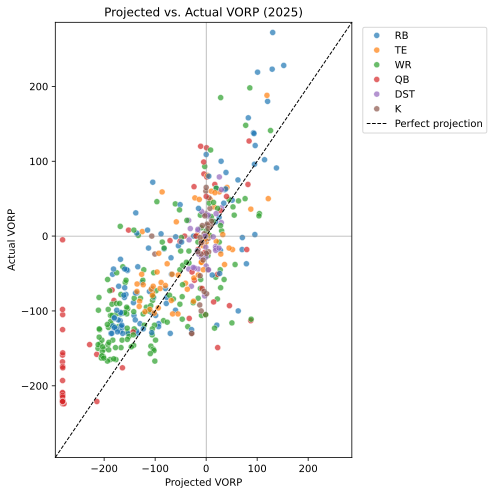

In [8]:
current_df = accuracy_df[accuracy_df["year"] == CURRENT_SEASON]

plt.figure(figsize=(7, 7))
sns.scatterplot(data=current_df, x="proj_vorp", y="actual_vorp", hue="position", alpha=0.7)
lo = min(current_df["proj_vorp"].min(), current_df["actual_vorp"].min()) * 1.05
hi = max(current_df["proj_vorp"].max(), current_df["actual_vorp"].max()) * 1.05
lims = [lo, hi]
plt.plot(lims, lims, "k--", linewidth=1, label="Perfect projection")
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlim(lims)
plt.ylim(lims)
plt.xlabel("Projected VORP")
plt.ylabel("Actual VORP")
plt.title(f"Projected vs. Actual VORP ({CURRENT_SEASON})")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_scatter.png")
plt.show()

## 5. Is VORP accuracy improving over time?

RMSE and MAE by season, to see whether ESPN's projections have gotten better, worse, or
stayed flat across the seasons we have data for, and whether 2025 (the headline season above)
is a typical year or an outlier relative to its own history.

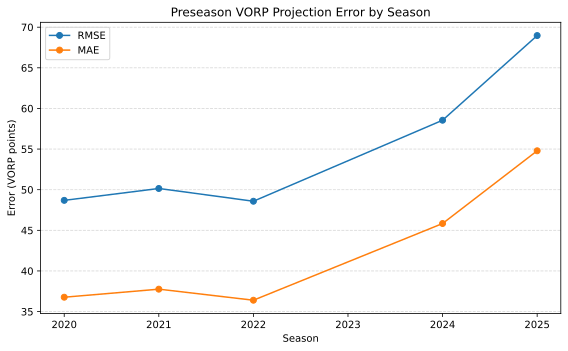

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(by_year.index, by_year["rmse"], marker="o", label="RMSE")
plt.plot(by_year.index, by_year["mae"], marker="o", label="MAE")
plt.xlabel("Season")
plt.ylabel("Error (VORP points)")
plt.title("Preseason VORP Projection Error by Season")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.savefig("../docs/charts/projection_accuracy_trend.png")
plt.show()

## 6. Biggest VORP misses (boom/bust), last season (2025)

The players whose *VORP* projections were most wrong in `CURRENT_SEASON` - biggest positive
`vorp_error` (`proj_vorp - actual_vorp`; projected far more value than they delivered -
"busts") and biggest negative `vorp_error` (delivered far more value than projected -
"booms"). Raw projected/actual points are included alongside for context, but the sort and
the headline number are VORP, since that's what would have actually changed a draft-day call.

In [10]:
cols = ["player_name", "position", "pro_team", "projected_points", "actual_points",
        "proj_vorp", "actual_vorp", "vorp_error"]

busts = current_df.sort_values("vorp_error", ascending=False).head(10)[cols].reset_index(drop=True)
booms = current_df.sort_values("vorp_error", ascending=True).head(10)[cols].reset_index(drop=True)

boom_bust = pd.concat(
    [busts.assign(type="bust (overprojected)"), booms.assign(type="boom (underprojected)")],
    ignore_index=True,
)
boom_bust.to_html("../docs/tables/projection_boom_bust.html", index=False)

print("Busts (overprojected VORP):")
display(busts)
print("Booms (underprojected VORP):")
display(booms)

Busts (overprojected VORP):


,player_name,position,pro_team,projected_points,actual_points,proj_vorp,actual_vorp,vorp_error
0,Jayden Daniels,QB,WSH,370.53,109.0,87.41,-113.0,200.41
1,Malik Nabers,WR,NYG,300.44,56.0,88.24,-111.0,199.24
2,Kyler Murray,QB,ARI,305.74,73.0,22.62,-149.0,171.62
3,Tyreek Hill,WR,0,262.72,51.0,50.52,-116.0,166.52
4,James Conner,RB,ARI,249.79,30.0,62.90,-100.0,162.90
5,Austin Ekeler,RB,WSH,207.77,11.0,20.88,-119.0,139.88
6,Calvin Ridley,WR,TEN,228.62,44.0,16.42,-123.0,139.42
7,Joe Burrow,QB,CIN,328.76,129.0,45.64,-93.0,138.64
8,Alvin Kamara,RB,NO,265.78,93.0,78.89,-37.0,115.89
9,Mike Evans,WR,TB,234.21,83.0,22.01,-84.0,106.01


Booms (underprojected VORP):


,player_name,position,pro_team,projected_points,actual_points,proj_vorp,actual_vorp,vorp_error
0,Jacoby Brissett,QB,ARI,1.64,217.0,-281.48,-5.0,-276.48
1,Mac Jones,QB,SF,1.51,124.0,-281.61,-98.0,-183.61
2,Parker Washington,WR,JAX,43.77,180.0,-168.43,13.0,-181.43
3,Rico Dowdle,RB,CAR,82.22,202.0,-104.67,72.0,-176.67
4,Marcus Mariota,QB,WSH,1.83,117.0,-281.29,-105.0,-176.29
5,Quinshon Judkins,RB,CLE,48.90,161.0,-137.99,31.0,-168.99
6,Jaxson Dart,QB,NYG,131.00,230.0,-152.12,8.0,-160.12
7,Jaxon Smith-Njigba,WR,SEA,240.65,352.0,28.45,185.0,-156.55
8,Kirk Cousins,QB,ATL,1.67,97.0,-281.45,-125.0,-156.45
9,Alec Pierce,WR,IND,70.50,175.0,-141.70,8.0,-149.70


## 7. The benchmark that actually matters: are these projections better than the market?

Every metric so far answers "how wrong were the projections". None of them answer the question a
drafter actually faces, which is comparative: **would I have done better ignoring my projections
and just drafting off ADP?** An RMSE of 66 VORP points is only bad if something else does better.

Average Draft Position is the crowd's ranking — the consensus of everyone else drafting. It's the
free alternative to any model, so it's the benchmark to beat.

**Why rank correlation and not RMSE.** ADP is a pick number (1, 2, 3, …); VORP is points above
replacement. They live on completely different scales, so an error metric between them is
meaningless. But drafting is fundamentally an *ordering* problem — you never need to know that a
player will score 214.7 points, only that he should go before the next guy on your board. Spearman
rank correlation against actual VORP measures exactly that, and works across both scales.

Three rankers are compared:

1. **`proj_vorp`** — ESPN's projection converted to VORP; what the draft board shows today
2. **`-adp`** — the market, negated so that "drafted earlier" sorts the same direction as "better"
3. **blend** — the average of the two ranks, testing whether they carry complementary information

**Coverage.** ADP is only on record from 2022 onward, and 2023 is excluded for the projection gap
described in §1, so the head-to-head runs on **2022, 2024, 2025**. Two seasons of that overlap are
consecutive and all three are one league's data — treat a small edge in either direction as noise,
not as a finding.

**One caveat that cuts against reading too much into a narrow win either way:** ADP is not
independent of ESPN's projections. A large share of the people setting ADP are looking at those
same projections when they draft. These are correlated rankers, not a controlled comparison.

In [11]:
from sqlalchemy import text

# ADP is only on record from 2022 onward, so the benchmark covers a shorter
# window than the accuracy analysis above. `avg` is the consensus overall pick
# number across sources (lower = drafted earlier = the market rates them higher).
adp = pd.read_sql(
    text("SELECT player_id, year, avg AS adp FROM average_draft_position WHERE avg IS NOT NULL"),
    engine,
)
# average_draft_position.player_id is declared CHAR(7) in the schema, so it
# comes back as text while players_stats.player_id is an integer - coerce
# before merging rather than silently getting zero matches.
adp["player_id"] = pd.to_numeric(adp["player_id"], errors="coerce")
adp = adp.dropna(subset=["player_id"])
adp["player_id"] = adp["player_id"].astype("int64")

bench_df = accuracy_df.merge(adp, on=["player_id", "year"], how="inner")
BENCH_YEARS = sorted(bench_df["year"].unique())

# Negate so that higher = better for every ranker, making the correlations
# directly comparable rather than one of them pointing the opposite way.
bench_df["market_score"] = -bench_df["adp"]
# Blend on *ranks*, not raw values - proj_vorp and adp aren't on a common scale,
# so averaging the values themselves would just be a noisy version of whichever
# has the larger spread.
bench_df["blend_score"] = (
    bench_df.groupby("year")["proj_vorp"].rank(pct=True)
    + bench_df.groupby("year")["market_score"].rank(pct=True)
) / 2

RANKERS = {
    "proj_vorp (ESPN)": "proj_vorp",
    "-adp (market)": "market_score",
    "blend of both": "blend_score",
}


def spearman_table(df, label):
    """Spearman rank correlation of each ranker against actual VORP, per season."""
    rows = []
    for year, grp in df.groupby("year"):
        row = {"scope": label, "year": year, "n": len(grp)}
        for name, col in RANKERS.items():
            row[name] = grp[col].corr(grp["actual_vorp"], method="spearman")
        rows.append(row)
    return pd.DataFrame(rows)


# The full pool flatters every ranker: separating stars from deep-bench players
# is easy and nobody agonises over it on draft day. Restricting to the top of
# the board asks the harder, decision-relevant question.
scopes = [("all players", bench_df)]
for top_n in (100, 50):
    top = (
        bench_df.sort_values("adp")
        .groupby("year", group_keys=False)
        .head(top_n)
    )
    scopes.append((f"top {top_n} by ADP", top))

spearman_df = pd.concat([spearman_table(df, label) for label, df in scopes], ignore_index=True)
print(f"ADP benchmark seasons: {BENCH_YEARS}  |  matched rows: {len(bench_df)}")
spearman_df.round(3)

ADP benchmark seasons: [np.int64(2022), np.int64(2024), np.int64(2025)]  |  matched rows: 1083


,scope,year,n,proj_vorp (ESPN),-adp (market),blend of both
0,all players,2022,254,0.595,0.529,0.588
1,all players,2024,389,0.736,0.620,0.706
2,all players,2025,440,0.744,0.586,0.699
3,top 100 by ADP,2022,100,0.434,0.462,0.474
4,top 100 by ADP,2024,100,0.496,0.419,0.486
5,top 100 by ADP,2025,100,0.499,0.404,0.488
6,top 50 by ADP,2022,50,0.370,0.483,0.432
7,top 50 by ADP,2024,50,0.485,0.303,0.440
8,top 50 by ADP,2025,50,0.618,0.552,0.609


### Hit rate: the plain-language version

Rank correlation is the right statistic but a hard one to feel. This asks the same question in
draft terms: **of the 24 players each ranker liked most, how many actually finished in the real
top 24 by VORP?** Twenty-four is roughly the first two rounds of a 14-team league — the picks that
decide a season.

In [12]:
TOP_N = 24  # ~first two rounds of a 14-team league

hit_rows = []
for year, grp in bench_df.groupby("year"):
    truth = set(grp.nlargest(TOP_N, "actual_vorp")["player_id"])
    row = {"year": str(year), "pool size": len(grp)}
    for name, col in RANKERS.items():
        picked = set(grp.nlargest(TOP_N, col)["player_id"])
        row[name] = len(picked & truth)
    hit_rows.append(row)

hit_df = pd.DataFrame(hit_rows)
mean_row = hit_df.drop(columns="year").mean().round(1).to_dict()
mean_row["year"] = "mean"
hit_df = pd.concat([hit_df, pd.DataFrame([mean_row])[hit_df.columns]], ignore_index=True)

print(f"Players correctly identified in the actual top {TOP_N} by VORP (out of {TOP_N}):")
hit_df

Players correctly identified in the actual top 24 by VORP (out of 24):


,year,pool size,proj_vorp (ESPN),-adp (market),blend of both
0,2022,254.0,10.0,13.0,11.0
1,2024,389.0,13.0,11.0,12.0
2,2025,440.0,15.0,13.0,15.0
3,mean,361.0,12.7,12.3,12.7


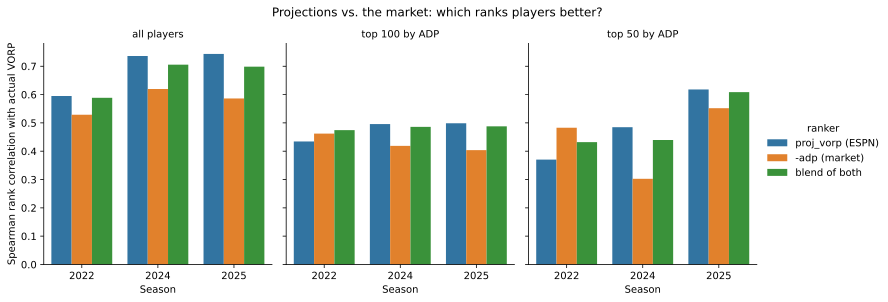

position,n,proj_vorp (ESPN),-adp (market),blend of both
RB,105,0.727000,0.638000,0.694000
TE,61,0.696000,0.617000,0.667000
WR,149,0.695000,0.629000,0.667000
QB,59,0.686000,0.675000,0.705000
K,34,0.534000,0.339000,0.453000
DST,32,0.406000,0.247000,0.379000


In [13]:
plot_df = spearman_df.melt(
    id_vars=["scope", "year"], value_vars=list(RANKERS),
    var_name="ranker", value_name="spearman",
)

g = sns.catplot(
    data=plot_df, x="year", y="spearman", hue="ranker", col="scope",
    kind="bar", height=4, aspect=0.9,
)
g.set_axis_labels("Season", "Spearman rank correlation with actual VORP")
g.set_titles("{col_name}")
g.figure.suptitle("Projections vs. the market: which ranks players better?", y=1.04)
g.figure.savefig("../docs/charts/adp_benchmark_spearman.png", bbox_inches="tight", dpi=150)
plt.show()

# Per-position view for the headline season - the aggregate can hide a ranker
# that wins overall purely by being better at one easy position.
current_bench = bench_df[bench_df["year"] == CURRENT_SEASON]
pos_rows = []
for position, grp in current_bench.groupby("position"):
    if len(grp) < 10:  # too few players to read a rank correlation from
        continue
    row = {"position": position, "n": len(grp)}
    for name, col in RANKERS.items():
        row[name] = grp[col].corr(grp["actual_vorp"], method="spearman")
    pos_rows.append(row)

by_position_bench = pd.DataFrame(pos_rows).sort_values("proj_vorp (ESPN)", ascending=False)
styled_bench = (
    by_position_bench.round(3).style.hide(axis="index")
    .set_caption(f"Rank correlation with actual VORP by position ({CURRENT_SEASON})")
)
styled_bench.to_html("../docs/tables/adp_benchmark_by_position.html")
styled_bench

### What the benchmark says

**Across the full pool, the projections beat the market — clearly and in every season.** Spearman
against actual VORP: 0.595 / 0.736 / 0.744 for `proj_vorp` in 2022 / 2024 / 2025, against
0.529 / 0.620 / 0.586 for ADP. That is not a rounding-error margin, and it settles the "am I just
doing worse than drafting off the crowd" worry: over the whole draftable pool, no.

**At the top of the board, the edge evaporates.** Restricted to the top 50 by ADP — the picks that
actually decide a season — the two rankers trade wins: ADP is better in 2022 (0.483 vs. 0.370),
the projections are better in 2024 (0.485 vs. 0.303) and 2025 (0.618 vs. 0.552). One win each way
plus a tiebreaker is not a track record.

**The hit rate is a dead heat.** Of 24 picks, the projections land 12.7 of the true top 24 on
average, ADP lands 12.3, and blending them lands 12.7. Roughly half right, whichever ranker you
use, every year.

**Blending doesn't help.** The blend never beats the better of its two inputs by a meaningful
margin, which is what you'd expect from two rankers that aren't independent — ADP is set largely by
people reading these same projections.

Putting this together with NB04's ablation, the picture is consistent:

| Question | Answer |
|---|---|
| Do better features improve the prediction? | No — `proj_vorp` alone matches the full feature set |
| Do the projections beat the market overall? | Yes, comfortably |
| Do they beat the market where it counts (top 50)? | Not reliably — roughly a coin flip |

So the answer to "should I try other prediction methods?" is: **the ranking signal is close to its
ceiling, and the remaining edge isn't in prediction at all.** Both rankers get about half the top
24 right and neither can do much better, because the difference between a projected top-24 finish
and an actual one is mostly injury, snap-share change, and touchdown variance — none of which
exist in July. Where value *is* still available: cross-position comparability (`add_vorp_z`),
roster-need and pick-timing logic, and knowing how wide the error bars are so you can prefer the
safe pick when the board is close.

## 8. Feed position reliability back into the live tool

Everything above is retrospective, but §3's by-position table contains something the live draft
tool can act on **today**: how much a projection at each position has historically been worth
trusting. R² is literally the share of variance in actual VORP that the projection explains, so it
works directly as a reliability weight in [0, 1] — QB 0.52 means "about half of what this number
claims has held up historically"; K −0.03 and DST 0.00 mean "this number has told you nothing".

This matters because NB04's bootstrap intervals, on their own, are **not** a good risk signal.
They measure *model* uncertainty — how much a Ridge fit wobbles when you resample the training
data — which is narrow, a few percent. What a drafter actually cares about is *outcome*
uncertainty: how wrong the projection will turn out to be. That is the quantity measured on this
page, it is far larger, and it varies enormously by position.

So this cell writes a `position_reliability` table that `src/recommender.py` joins and
`src/scoring.py` blends with the model interval into a single confidence figure. Combining the two
is deliberate: the interval distinguishes players *within* a position, the R² distinguishes
*between* positions, and neither alone is enough.

Same contract as `model_projections`: the table is optional, and the live tool falls back to
treating every position as equally reliable if this notebook has never run.

In [14]:
reliability_df = by_position.reset_index()[["position", "n", "rmse", "mae", "r2"]].copy()

# R^2 is already "share of variance in actual VORP explained by the projection",
# so it needs no rescaling to serve as a weight - only a floor at 0, since a
# negative R^2 ("worse than guessing the mean") is still just no information,
# not negative information.
reliability_df["reliability"] = reliability_df["r2"].clip(lower=0.0)
reliability_df["seasons"] = ",".join(str(y) for y in YEARS)

reliability_df.to_sql("position_reliability", engine, if_exists="replace", index=False)

# --- Rookie status, as a factor relative to veterans (see 3b) -----------------
# Stored as a ratio, not a second absolute reliability: position and rookie
# status are separate axes, so the live tool composes them multiplicatively
# rather than letting one overwrite the other.
vet_r2 = max(float(by_rookie.loc["veteran", "r2"]), 1e-6)
rookie_r2 = max(float(by_rookie.loc["rookie", "r2"]), 0.0)
rookie_factor = min(rookie_r2 / vet_r2, 1.0)

rookie_reliability_df = by_rookie.rename_axis("group").reset_index()
rookie_reliability_df["reliability_factor"] = [
    1.0 if g == "veteran" else rookie_factor for g in rookie_reliability_df["group"]
]
rookie_reliability_df["seasons"] = ",".join(str(y) for y in sorted(rookie_df["year"].unique()))
rookie_reliability_df.to_sql("rookie_reliability", engine, if_exists="replace", index=False)

print(f"Wrote {len(reliability_df)} rows to position_reliability "
      f"(seasons {YEARS}, 2023 excluded)")
print(f"Wrote rookie_reliability: a rookie projection is worth "
      f"{rookie_factor:.0%} of a veteran's at the same position "
      f"(R^2 {rookie_r2:.3f} vs {vet_r2:.3f})")
print(f"Rookies out-deliver their projections by "
      f"{-float(by_rookie.loc['rookie', 'mean_signed_error']):.1f} VORP on average, "
      f"vs {-float(by_rookie.loc['veteran', 'mean_signed_error']):.1f} for veterans")
reliability_df.sort_values("reliability", ascending=False).round(3)

Wrote 6 rows to position_reliability (seasons [2020, 2021, 2022, 2024, 2025], 2023 excluded)
Wrote rookie_reliability: a rookie projection is worth 61% of a veteran's at the same position (R^2 0.280 vs 0.460)
Rookies out-deliver their projections by 27.3 VORP on average, vs 8.2 for veterans


,position,n,rmse,mae,r2,reliability,seasons
0,QB,277.0,79.18,62.56,0.52,0.52,"2020,2021,2022,2024,2025"
1,RB,550.0,59.95,46.88,0.42,0.42,"2020,2021,2022,2024,2025"
2,WR,714.0,53.79,42.31,0.37,0.37,"2020,2021,2022,2024,2025"
4,TE,311.0,38.99,30.14,0.37,0.37,"2020,2021,2022,2024,2025"
3,K,162.0,43.61,31.75,-0.03,0.00,"2020,2021,2022,2024,2025"
5,DST,160.0,35.49,28.62,0.00,0.00,"2020,2021,2022,2024,2025"


## 8. Takeaways

**On the projections themselves.** Preseason VORP projections explain roughly a third to a half of
the variance in delivered VORP (R² 0.34–0.54 across 2020–2025), with a typical miss of 37–55 VORP
points. 2025 was the *worst* season on record here — R² 0.34 against a 0.45–0.54 band in the other
four years — and it ran systematically low (mean signed error −23.6, i.e. players out-delivered
their projections on average). That's one season, not a trend.

**On position.** Accuracy varies sharply and not in the direction folklore suggests. QB projections
have the largest absolute errors (RMSE 79.2) simply because QB scores are largest, but explain the
most variance (R² 0.52). Kickers (R² −0.03) and defenses (0.00) are genuinely unpredictable —
projecting them is no better than projecting the average. That is a concrete argument for not
spending early picks on either.

**On whether to try harder.** Two independent checks say the ranking is near its ceiling:

- **NB04's ablation** — adding last season's scoring, usage volume, usage rate, and a rookie flag
  to `proj_vorp` changes holdout R² by less than 0.01. The features aren't weak; they're already
  baked into ESPN's projection.
- **§7's ADP benchmark** — the projections beat the market across the full pool, but at the top 50
  it's a coin flip, and both rankers correctly identify only about half the true top 24.

The honest conclusion is that the remaining error is mostly *unforecastable in July*: injuries,
snap-share changes, coaching decisions, touchdown variance. A better model doesn't reach it.

**Where the leverage actually is,** given the above:

- **Cross-position comparability** (`add_vorp_z` in `src/scoring.py`) — changes which player the
  *same* projection recommends, which is a real edge that costs no prediction accuracy.
- **Uncertainty, used deliberately** — NB04's bootstrap intervals are wide for a reason. When two
  players are close on the board, the one with the narrower interval is the better pick, and this
  notebook's error spread is the evidence for how wide those intervals should be.
- **Roster need and pick timing** — `score()`'s need weighting and `adp_pressure` operate on
  information the projection doesn't contain at all.

**Scope.** This notebook is standalone: it isn't wired into `docs/index.qmd` or the live API, so
re-running it doesn't affect the published site or the draft tool. It does write two tables and two
charts into `docs/` for reference.